In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.style.use('ggplot')

In [3]:
df = pd.read_csv("data_bal/data_balanceada.csv")

print(f"Dimensiones: {df.shape}")
print(f"\nColumnas: {list(df.columns)}")
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nBalance de clases (es_muerte_natural):")
print(df['es_muerte_natural'].value_counts())
print(f"\nPorcentaje:")
print(df['es_muerte_natural'].value_counts(normalize=True).round(4) * 100)
print(f"\nNulos:")
print(df.isnull().sum())

Dimensiones: (185670, 7)

Columnas: ['anio', 'mes', 'dia', 'depto', 'edad', 'sexo', 'es_muerte_natural']

Tipos de datos:
anio                 float64
mes                  float64
dia                  float64
depto                float64
edad                 float64
sexo                 float64
es_muerte_natural    float64
dtype: object

Balance de clases (es_muerte_natural):
es_muerte_natural
0.0    92835
1.0    92835
Name: count, dtype: int64

Porcentaje:
es_muerte_natural
0.0    50.0
1.0    50.0
Name: proportion, dtype: float64

Nulos:
anio                 0
mes                  0
dia                  0
depto                0
edad                 0
sexo                 0
es_muerte_natural    0
dtype: int64


In [4]:
X = df.drop(columns=['es_muerte_natural'])
y = df['es_muerte_natural']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    train_size=0.8,
    random_state=42,
    stratify=y
)

print(f"Entrenamiento : {X_train.shape[0]:,} registros")
print(f"Prueba        : {X_test.shape[0]:,} registros")
print(f"\nBalance en entrenamiento:")
print(y_train.value_counts())
print(f"\nBalance en prueba:")
print(y_test.value_counts())

Entrenamiento : 148,536 registros
Prueba        : 37,134 registros

Balance en entrenamiento:
es_muerte_natural
1.0    74268
0.0    74268
Name: count, dtype: int64

Balance en prueba:
es_muerte_natural
0.0    18567
1.0    18567
Name: count, dtype: int64


In [5]:
# One-Hot Encoding de depto y sexo para Regresión Logística
cols_ohe = ['depto', 'sexo']
cols_num = ['anio', 'mes', 'dia', 'edad']

X_lr_train = pd.get_dummies(X_train, columns=cols_ohe, drop_first=False)
X_lr_test  = pd.get_dummies(X_test,  columns=cols_ohe, drop_first=False)

# Alinear columnas por si alguna categoría no aparece en test
X_lr_train, X_lr_test = X_lr_train.align(X_lr_test, join='left', axis=1, fill_value=0)

# Escalado: ajustar SOLO en train, aplicar a ambos
scaler = StandardScaler()
X_lr_train_sc = scaler.fit_transform(X_lr_train)
X_lr_test_sc  = scaler.transform(X_lr_test)

print(f"Columnas después de OHE: {X_lr_train.shape[1]}")
print(f"X_lr_train_sc shape: {X_lr_train_sc.shape}")
print(f"X_lr_test_sc  shape: {X_lr_test_sc.shape}")

Columnas después de OHE: 29
X_lr_train_sc shape: (148536, 29)
X_lr_test_sc  shape: (37134, 29)


In [6]:
logReg = LogisticRegression(max_iter=1000)

solvers  = ['newton-cg', 'lbfgs', 'liblinear']
penalty  = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]

grid = dict(solver=solvers, penalty=penalty, C=c_values)
cv   = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

grid_search = GridSearchCV(estimator=logReg, param_grid=grid,
                           n_jobs=-1, cv=cv, scoring='accuracy', error_score=0)
grid_result = grid_search.fit(X_lr_train_sc, y_train)

print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means  = grid_result.cv_results_['mean_test_score']
stds   = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.770538 using {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.770511 (0.004121) with: {'C': 100, 'penalty': 'l2', 'solver': 'newton-cg'}
0.770538 (0.004109) with: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
0.770529 (0.004114) with: {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}
0.770511 (0.004121) with: {'C': 10, 'penalty': 'l2', 'solver': 'newton-cg'}
0.770538 (0.004109) with: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
0.770529 (0.004114) with: {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
0.770511 (0.004117) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'newton-cg'}
0.770538 (0.004109) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
0.770520 (0.004113) with: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}
0.770502 (0.004122) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'newton-cg'}
0.770518 (0.004110) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
0.770520 (0.004111) with: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
0.770433 (0.004147) with: {

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

         0.0       0.76      0.80      0.78     18567
         1.0       0.79      0.74      0.76     18567

    accuracy                           0.77     37134
   macro avg       0.77      0.77      0.77     37134
weighted avg       0.77      0.77      0.77     37134



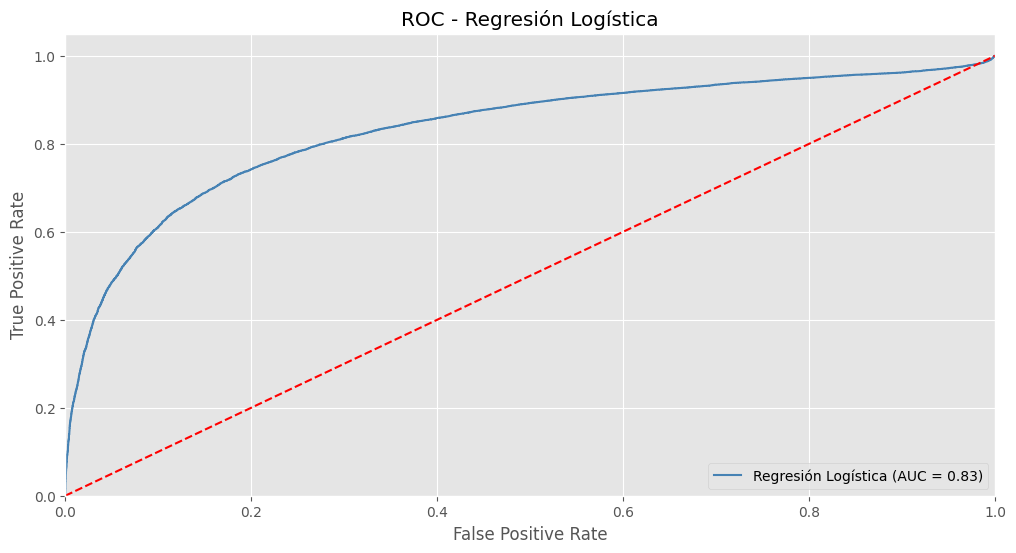

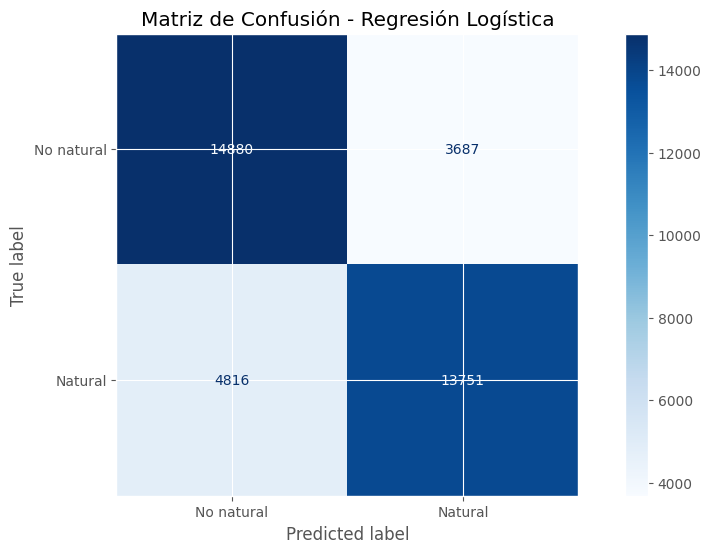

In [7]:
best_lr = grid_result.best_estimator_

y_pred_lr = best_lr.predict(X_lr_test_sc)

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr))

# Curva ROC
logit_roc_auc = roc_auc_score(y_test, best_lr.predict_proba(X_lr_test_sc)[:, 1])
fpr, tpr, _ = roc_curve(y_test, best_lr.predict_proba(X_lr_test_sc)[:, 1])

plt.figure()
plt.plot(fpr, tpr, label='Regresión Logística (AUC = %0.2f)' % logit_roc_auc, color='steelblue')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Regresión Logística')
plt.legend(loc='lower right')
plt.show()

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No natural', 'Natural'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

In [ ]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth'   : [8, 16, None],
    'max_features': ['sqrt', 'log2']
}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf,
                               n_jobs=-1, cv=cv, scoring='accuracy', error_score=0)
grid_result_rf = grid_search_rf.fit(X_train, y_train)

print("Best: %f using %s" % (grid_result_rf.best_score_, grid_result_rf.best_params_))
means  = grid_result_rf.cv_results_['mean_test_score']
stds   = grid_result_rf.cv_results_['std_test_score']
params = grid_result_rf.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

In [8]:
rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth'   : [8, 12],
    'max_features': ['sqrt', 'log2']
}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

grid_search_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf,
                              n_jobs=-1, cv=cv, scoring='accuracy', error_score=0)
grid_result_rf = grid_search_rf.fit(X_train, y_train)

print("Best: %f using %s" % (grid_result_rf.best_score_, grid_result_rf.best_params_))
means  = grid_result_rf.cv_results_['mean_test_score']
stds   = grid_result_rf.cv_results_['std_test_score']
params = grid_result_rf.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.887628 using {'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 200}
0.882632 (0.002745) with: {'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 100}
0.882558 (0.002767) with: {'max_depth': 8, 'max_features': 'sqrt', 'n_estimators': 200}
0.882632 (0.002745) with: {'max_depth': 8, 'max_features': 'log2', 'n_estimators': 100}
0.882558 (0.002767) with: {'max_depth': 8, 'max_features': 'log2', 'n_estimators': 200}
0.887585 (0.002547) with: {'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 100}
0.887628 (0.002596) with: {'max_depth': 12, 'max_features': 'sqrt', 'n_estimators': 200}
0.887585 (0.002547) with: {'max_depth': 12, 'max_features': 'log2', 'n_estimators': 100}
0.887628 (0.002596) with: {'max_depth': 12, 'max_features': 'log2', 'n_estimators': 200}


=== RANDOM FOREST ===
              precision    recall  f1-score   support

         0.0       0.87      0.90      0.89     18567
         1.0       0.90      0.87      0.88     18567

    accuracy                           0.88     37134
   macro avg       0.89      0.88      0.88     37134
weighted avg       0.89      0.88      0.88     37134



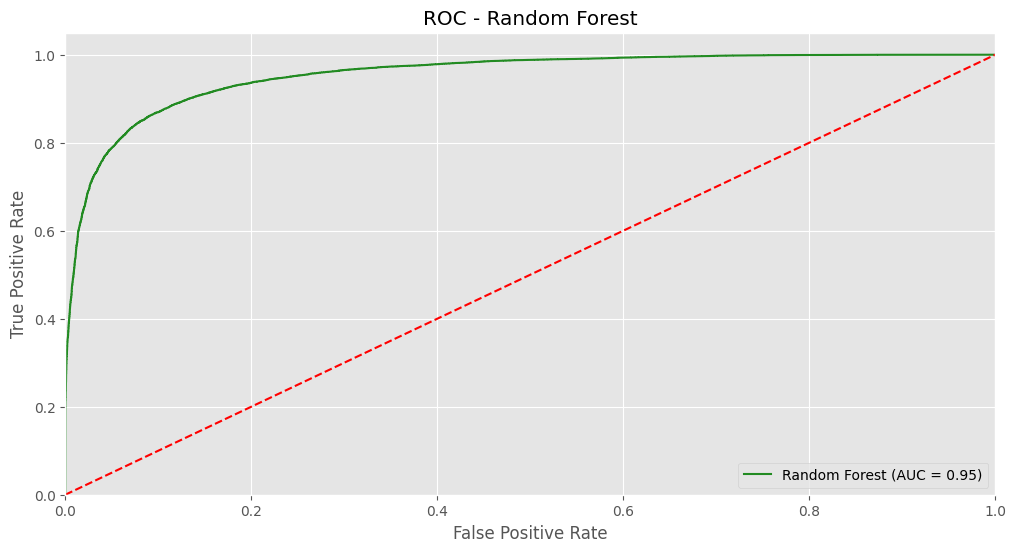

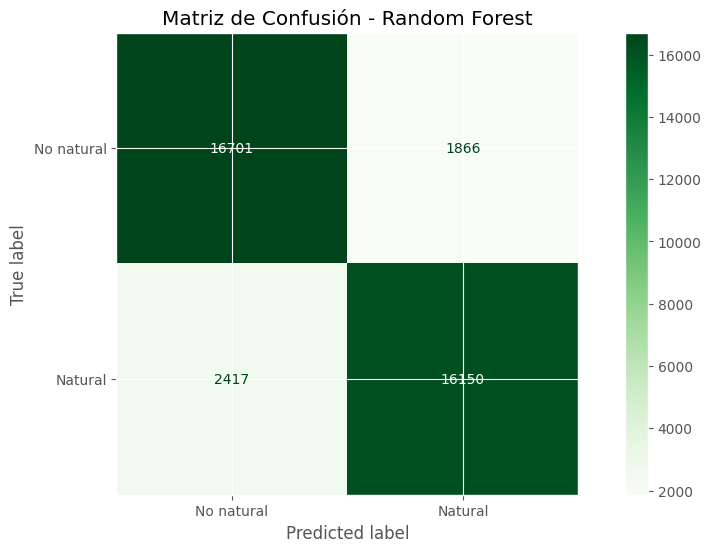

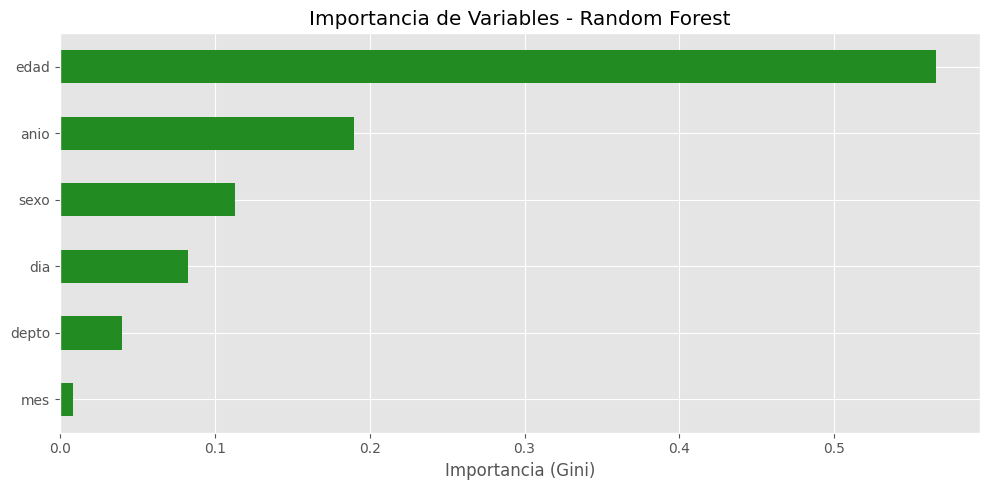

In [9]:
best_rf = grid_result_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

# Curva ROC
rf_roc_auc = roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, best_rf.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % rf_roc_auc, color='forestgreen')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Random Forest')
plt.legend(loc='lower right')
plt.show()

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No natural', 'Natural'])
disp_rf.plot(cmap='Greens')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

# Importancia de variables
importancias = pd.Series(best_rf.feature_importances_, index=X_train.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importancias.plot(kind='barh', color='forestgreen')
plt.title('Importancia de Variables - Random Forest')
plt.xlabel('Importancia (Gini)')
plt.tight_layout()
plt.show()

In [10]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

param_grid_xgb = {
    'max_depth'    : [4, 6],
    'learning_rate': [0.05, 0.1],
    'n_estimators' : [200, 500]
}

cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)

grid_search_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb,
                               n_jobs=-1, cv=cv, scoring='accuracy', error_score=0)
grid_result_xgb = grid_search_xgb.fit(X_train, y_train)

print("Best: %f using %s" % (grid_result_xgb.best_score_, grid_result_xgb.best_params_))
means  = grid_result_xgb.cv_results_['mean_test_score']
stds   = grid_result_xgb.cv_results_['std_test_score']
params = grid_result_xgb.cv_results_['params']
for mean, stdev, param in zip(means, stds, params):
    print("%f (%f) with: %r" % (mean, stdev, param))

Best: 0.890332 using {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500}
0.888970 (0.002601) with: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200}
0.890332 (0.002505) with: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 500}
0.890238 (0.002537) with: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}
0.890170 (0.002374) with: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 500}
0.890211 (0.002616) with: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
0.890184 (0.002586) with: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 500}
0.890280 (0.002452) with: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
0.889434 (0.002698) with: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 500}


=== XGBOOST ===
              precision    recall  f1-score   support

         0.0       0.88      0.90      0.89     18567
         1.0       0.90      0.87      0.89     18567

    accuracy                           0.89     37134
   macro avg       0.89      0.89      0.89     37134
weighted avg       0.89      0.89      0.89     37134



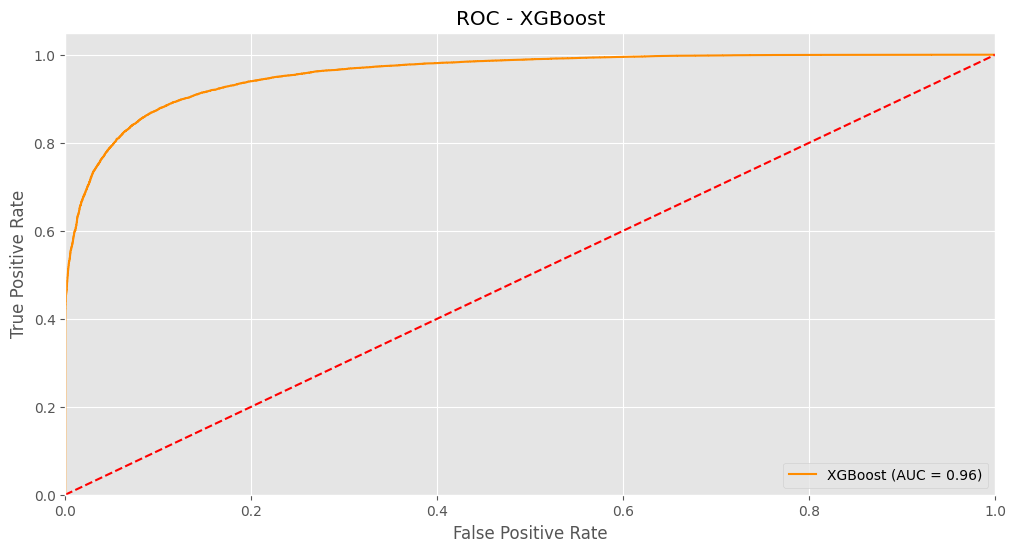

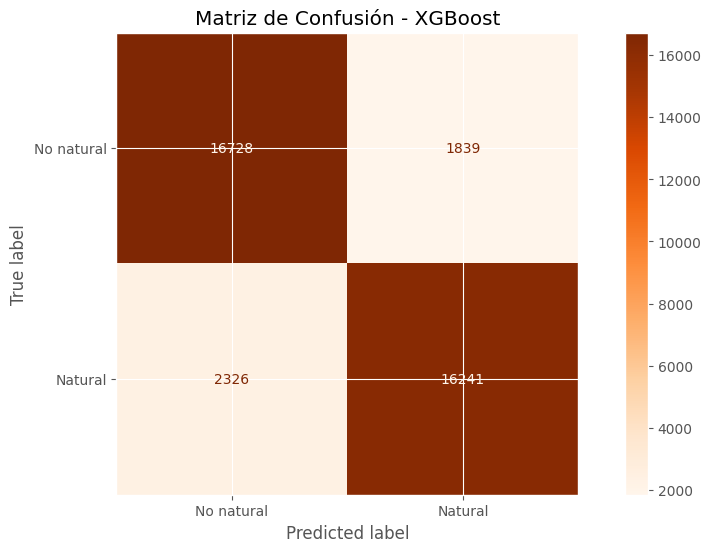

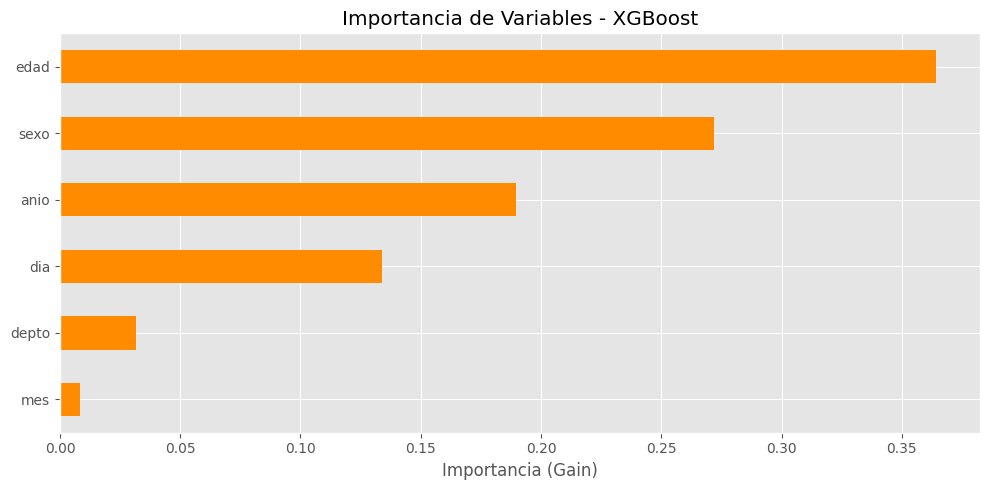

In [11]:
best_xgb = grid_result_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)

print("=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))

# Curva ROC
xgb_roc_auc = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, best_xgb.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %0.2f)' % xgb_roc_auc, color='darkorange')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - XGBoost')
plt.legend(loc='lower right')
plt.show()

# Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No natural', 'Natural'])
disp_xgb.plot(cmap='Oranges')
plt.title('Matriz de Confusión - XGBoost')
plt.show()

# Importancia de variables
importancias_xgb = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importancias_xgb = importancias_xgb.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importancias_xgb.plot(kind='barh', color='darkorange')
plt.title('Importancia de Variables - XGBoost')
plt.xlabel('Importancia (Gain)')
plt.tight_layout()
plt.show()

=== COMPARACIÓN FINAL DE MODELOS ===
             Modelo  Accuracy  AUC-ROC  F1 No Natural  F1 Natural
Regresión Logística    0.7710   0.8324           0.78        0.76
      Random Forest    0.8847   0.9541           0.89        0.88
            XGBoost    0.8878   0.9578           0.89        0.89


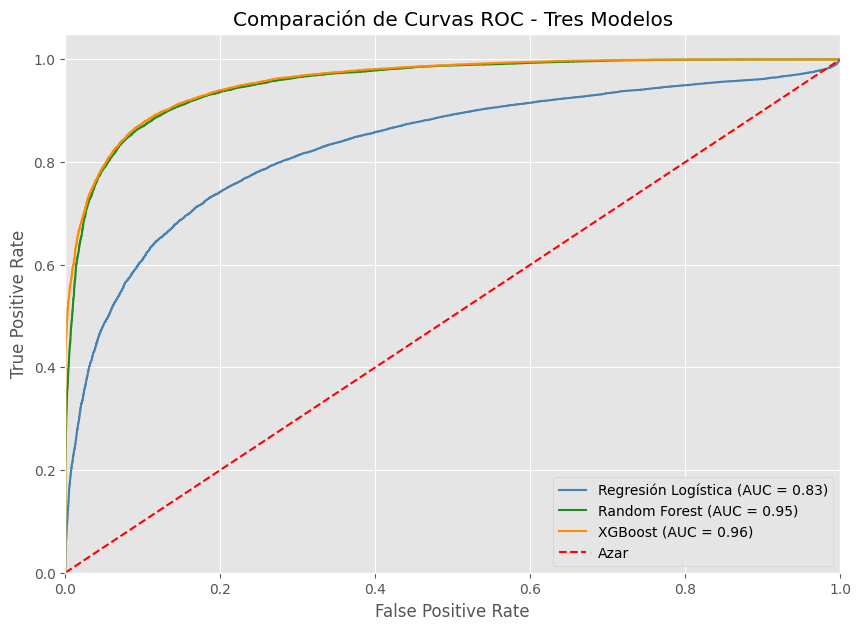

In [12]:
# Tabla resumen
resumen = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        round(grid_result.best_estimator_.score(X_lr_test_sc, y_test), 4),
        round(best_rf.score(X_test, y_test), 4),
        round(best_xgb.score(X_test, y_test), 4)
    ],
    'AUC-ROC': [
        round(roc_auc_score(y_test, grid_result.best_estimator_.predict_proba(X_lr_test_sc)[:, 1]), 4),
        round(roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]), 4),
        round(roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1]), 4)
    ],
    'F1 No Natural': [
        round(0.78, 4),
        round(0.89, 4),
        round(0.89, 4)
    ],
    'F1 Natural': [
        round(0.76, 4),
        round(0.88, 4),
        round(0.89, 4)
    ]
})

print("=== COMPARACIÓN FINAL DE MODELOS ===")
print(resumen.to_string(index=False))

# Curvas ROC superpuestas
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr,
         label='Regresión Logística (AUC = %0.2f)' % logit_roc_auc, color='steelblue')
plt.plot(fpr_rf, tpr_rf,
         label='Random Forest (AUC = %0.2f)' % rf_roc_auc, color='forestgreen')
plt.plot(fpr_xgb, tpr_xgb,
         label='XGBoost (AUC = %0.2f)' % xgb_roc_auc, color='darkorange')
plt.plot([0, 1], [0, 1], 'r--', label='Azar')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Comparación de Curvas ROC - Tres Modelos')
plt.legend(loc='lower right')
plt.show()